# elastic pressure independent material

In [ ]:
# Created by Zhaohui Yang (zhyang@ucsd.edu)
# elastic pressure independent material
# plane strain,  single element,  dynamic analysis (input motion: sinusoidal acceleration at base)
# SI units (m, s, KN, ton)
#
#         4     3
#         o-----o
#         |     |
#         |     |
#         |     |
#       1 o-----o 2   (nodes 1 and 2 fixed)
#         ^     ^
#          <--> input motion: sinusoidal acceleration at base

from math import cos, sin
import os
os.environ["XARA_COMPATIBILITY_VERSION"] = "O3"

import xara


In [2]:

#
#some user defined variables
#
accMul = 9.81
massDen = 2.000      # solid mass density
fluidDen = 1.0       # fluid mass density
massProportionalDamping = 0.0
stiffnessProportionalDamping = 0.001
cohesion = 30
peakShearStrain = 0.1
E1 = 90000.0         #Young's modulus
poisson1 = 0.40
G = E1 / (2 * (1 + poisson1))
B = E1 / (3 * (1 - 2 * poisson1))
press = 0            # isotropic consolidation pressure on quad element(s)

period = 1           # Period of applied sinusoidal load
deltaT = 0.01        # time step for analysis
numSteps = 2000      # Number of analysis steps
gamma = 0.5          # Newmark integration parameter
pi = 3.1415926535
inclination = 0
unitWeightX = (massDen - fluidDen) * 9.81 * sin(inclination / 180.0 * pi)   # buoyant unit weight in X direction
unitWeightY = -(massDen - fluidDen) * 9.81 * cos(inclination / 180.0 * pi) # buoyant unit weight in Y direction

In [3]:
# create the ModelBuilder
model = xara.Model(ndm=2, ndf=2)

# define material and properties
model.nDMaterial("PressureIndependMultiYield", 2, 2, 
                 massDen, G, B, cohesion, peakShearStrain)
model.nDMaterial("FluidSolidPorous", 1, 2, 2, 2.2e6)

# define the nodes
model.node(1, 0.0, 0.0)
model.node(2, 1.0, 0.0)
model.node(3, 1.0, 1.0)
model.node(4, 0.0, 1.0)

# fix the base in vertical direction
model.fix(1, 1, 1)
model.fix(2, 1, 1)

# define the element      thick  material      maTag   press  density  gravity
model.element("quad", 1, (1, 2, 3, 4), 
              1.0, "PlaneStrain", 2, 
              press, 0.0, 
              unitWeightX, unitWeightY)

model.updateMaterialStage(material=2, stage=0)



### GRAVITY APPLICATION (elastic behavior)

In [4]:

# create the SOE, ConstraintHandler, Integrator, Algorithm and Numberer
model.system("ProfileSPD")
model.test("NormDispIncr", 1.0e-12, 25, 0)
model.constraints("Transformation")
model.integrator("LoadControl", 1)
model.algorithm("Newton")
model.numberer("RCM")

# create the Analysis
model.analysis("Static")

# analyze
model.analyze(2)

0

In [5]:

# NOW APPLY LOADING SEQUENCE AND ANALYZE (plastic)
# rezero time
model.setTime(0.0)
model.wipeAnalysis()

model.equalDOF(3, 4, 1, 2)    #tie nodes 3 and 4

# create a LoadPattern
model.timeSeries("Sine", 1, 0, 10, "-factor", accMul, period=period)
model.pattern("UniformExcitation", 1, 1, "-accel", 1)

# create the Analysis
model.constraints("Penalty", 1.0e18, 1.0e18)  # Transformation;  #
model.test("NormDispIncr", 1.0e-12, 25, 0)
model.algorithm("Newton")
model.numberer("RCM")
model.system("ProfileSPD")
model.rayleigh(massProportionalDamping, 0.0, stiffnessProportionalDamping, 0.0)
model.integrator("Newmark", gamma, (gamma + 0.5) ** 2 / 4)
model.analysis("VariableTransient")


In [6]:
# create the recorders
model.recorder("Node", "-file", "out/disp.out", "-time", "-node", 1, 2, 3, 4, "-dof", 1, 2, "-dT", 0.01, "disp")
model.recorder("Node", "-file", "out/acce.out", "-time", "-node", 1, 2, 3, 4, "-dof", 1, 2, "-dT", 0.01, "accel")
model.recorder("Element", "-ele", 1, "-time", "-file", "out/stress1.out", "-dT", 0.01, "material", 1, "stress")
model.recorder("Element", "-ele", 1, "-time", "-file", "out/strain1.out", "-dT", 0.01, "material", 1, "strain")
model.recorder("Element", "-ele", 1, "-time", "-file", "out/stress3.out", "-dT", 0.01, "material", 3, "stress")
model.recorder("Element", "-ele", 1, "-time", "-file", "out/strain3.out", "-dT", 0.01, "material", 3, "strain")

5

In [7]:
# analyze
model.analyze(numSteps, deltaT, deltaT / 100, deltaT, 10)



0

In [8]:

model.wipe()  #flush ouput stream

In [9]:
import matplotlib.pyplot as plt
import numpy as np

a1 = np.loadtxt("out/acce.out")
d1 = np.loadtxt("out/disp.out")
s1 = np.loadtxt("out/stress1.out")
e1 = np.loadtxt("out/strain1.out")
s5 = np.loadtxt("out/stress3.out")
e5 = np.loadtxt("out/strain3.out")

fs = [0.5, 0.2, 4, 6]
accMul = 9.81

In [10]:
a1, d1, s1, e1, s5, e5

(array([[ 1.00000e-02, -7.22261e-14, -2.02248e-13, ..., -1.91516e-13,
         -3.13586e-01, -2.03787e-13],
        [ 2.00000e-02,  1.87094e-13,  5.89430e-13, ...,  4.90960e-13,
         -6.14796e-02,  4.81202e-13],
        [ 3.00000e-02, -3.03005e-13, -9.77752e-13, ..., -5.35106e-13,
          2.52445e-01, -5.40268e-13],
        ...,
        [ 1.99800e+01,  2.27498e-10,  7.83819e-10, ...,  2.20242e-12,
          3.56443e-12, -1.75462e-12],
        [ 1.99900e+01, -2.27605e-10, -7.84211e-10, ..., -2.20299e-12,
         -3.56506e-12,  1.75524e-12],
        [ 2.00000e+01,  2.27713e-10,  7.84604e-10, ...,  2.20356e-12,
          3.56573e-12, -1.75585e-12]], shape=(2000, 9)),
 array([[ 1.00000e-02, -1.80565e-18, -5.05619e-18, ..., -3.74020e-05,
         -2.57926e-05, -3.74020e-05],
        [ 2.00000e-02, -2.54525e-18, -5.48902e-18, ..., -3.74020e-05,
         -5.08486e-05, -3.74020e-05],
        [ 3.00000e-02, -3.31090e-18, -5.95033e-18, ..., -3.74020e-05,
         -8.05071e-05, -3.74020e-0

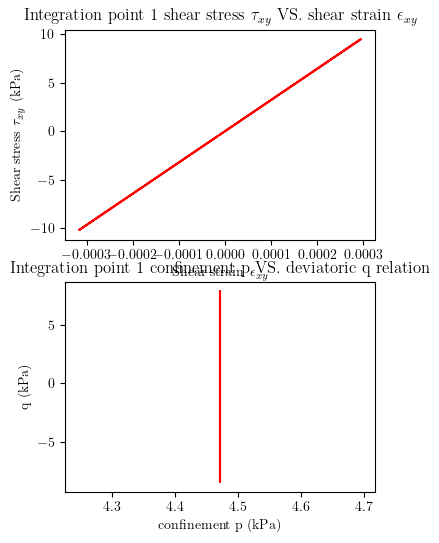

In [11]:
#integration point 1 p-q
po = (s1[:, 1] + s1[:, 2] + s1[:, 3]) / 3
qo = (
    (s1[:, 1] - s1[:, 2]) ** 2
    + (s1[:, 2] - s1[:, 3]) ** 2
    + (s1[:, 1] - s1[:, 3]) ** 2
    + 6.0 * s1[:, 4] ** 2
)
qo = np.sign(s1[:, 4]) / 3.0 * qo ** 0.5

plt.figure(1)
plt.clf()

#integration point 1 stress-strain
plt.subplot(2, 1, 1)
plt.plot(e1[:, 3], s1[:, 4], "r")
plt.title(r"Integration point 1 shear stress $\tau_{xy}$ VS. shear strain $\epsilon_{xy}$")
plt.xlabel(r"Shear strain $\epsilon_{xy}$")
plt.ylabel(r"Shear stress $\tau_{xy}$ (kPa)")

plt.subplot(2, 1, 2)
plt.plot(-po, qo, "r")
plt.title("Integration point 1 confinement p VS. deviatoric q relation")
plt.xlabel("confinement p (kPa)")
plt.ylabel("q (kPa)")
plt.gcf().set_size_inches(fs[2], fs[3])
# plt.savefig("SS_PQ1.jpg")

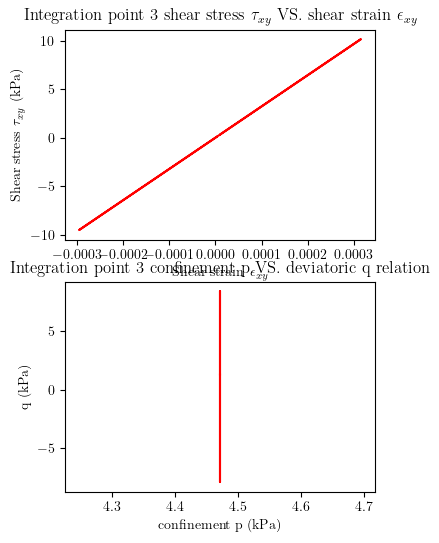

In [12]:
#integration point 3 p-q
po = (s5[:, 1] + s5[:, 2] + s5[:, 3]) / 3
qo = (
    (s5[:, 1] - s5[:, 2]) ** 2
    + (s5[:, 2] - s5[:, 3]) ** 2
    + (s5[:, 1] - s5[:, 3]) ** 2
    + 6.0 * s5[:, 4] ** 2
)
qo = np.sign(s5[:, 4]) / 3.0 * qo ** 0.5

plt.figure(4, figsize=(fs[2], fs[3]))
plt.clf()

#integration point 3 stress-strain
plt.subplot(2, 1, 1)
plt.plot(e5[:, 3], s5[:, 4], "r")
plt.title(r"Integration point 3 shear stress $\tau_{xy}$ VS. shear strain $\epsilon_{xy}$")
plt.xlabel(r"Shear strain $\epsilon_{xy}$")
plt.ylabel(r"Shear stress $\tau_{xy}$ (kPa)")

plt.subplot(2, 1, 2)
plt.plot(-po, qo, "r")
plt.title("Integration point 3 confinement p VS. deviatoric q relation")
plt.xlabel("confinement p (kPa)")
plt.ylabel("q (kPa)")
plt.gcf().set_size_inches(fs[2], fs[3])
# plt.savefig("SS_PQ5.jpg")

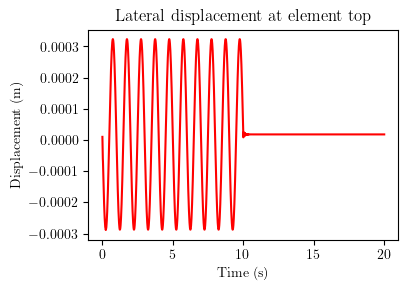

In [13]:
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()

#node 3 displacement relative to node 1
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 5], "r")
plt.title("Lateral displacement at element top")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.gcf().set_size_inches(fs[2], fs[3])
# plt.savefig("D.jpg")

Text(0, 0.5, 'Acceleration (m/s$^2$)')

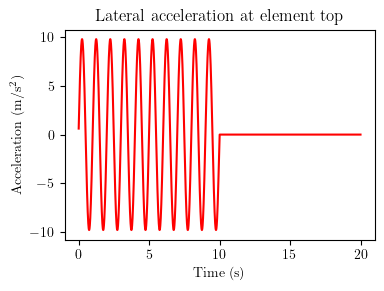

In [14]:
s = accMul * np.sin(np.linspace(0.0, 20.0 * np.pi, 1001))
s = np.concatenate((s, np.zeros(1000)))
s1 = np.interp(a1[:, 0], np.linspace(0.0, 20.0, 2001), s)

plt.figure(3, figsize=(fs[2], fs[3]))
plt.clf()

# node 3 relative acceleration
plt.subplot(2, 1, 1)
plt.plot(a1[:, 0], s1 + a1[:, 4], "r")
plt.title("Lateral acceleration at element top")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s$^2$)")
# plt.savefig("A.jpg")